In [2]:
import torch
from IPython.display import Image

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.6.0+cu124
CUDA available: False


In [5]:
%%writefile dataset/dataset.yaml
path: ../dataset
train: images/train
val: images/val
test: images/test

nc: 5
names: ['Car', 'Motorcycle', 'Truck', 'Bus', 'Bicycle']

Overwriting dataset/dataset.yaml


In [6]:
!python yolov5/train.py \
    --img 640 \
    --batch 16 \
    --epochs 50 \
    --data dataset/dataset.yaml \
    --weights yolov5s.pt \
    --cache ram

2025-04-06 16:50:39.158762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743951039.227675 2062762 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743951039.243616 2062762 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743951039.337542 2062762 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743951039.337575 2062762 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743951039.337578 2062762 computation_placer.cc:177] computation placer alr

In [7]:
!python yolov5/detect.py \
    --weights yolov5/runs/train/exp/weights/best.pt \
    --source dataset/images/test \
    --conf 0.25 \
    --save-txt \
    --save-conf

detect: weights=['yolov5/runs/train/exp/weights/best.pt'], source=dataset/images/test, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.11.11 torch-2.6.0+cu124 CPU

Fusing layers... 
Model summary: 157 layers, 7023610 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /home/daniel/Data/dhbw/CNNsForCarDetection/AdditionalSolution/dataset/images/test/img1027.jpg: 640x640 1 Bus, 57.1ms
image 2/8 /home/daniel/Data/dhbw/CNNsForCarDetection/AdditionalSolution/dataset/images/test/img1028.jpg: 640x640 1 Car, 48.2ms
image 3/8 /home/daniel/Data/dhbw/CNNsForCarDetection/AdditionalSo

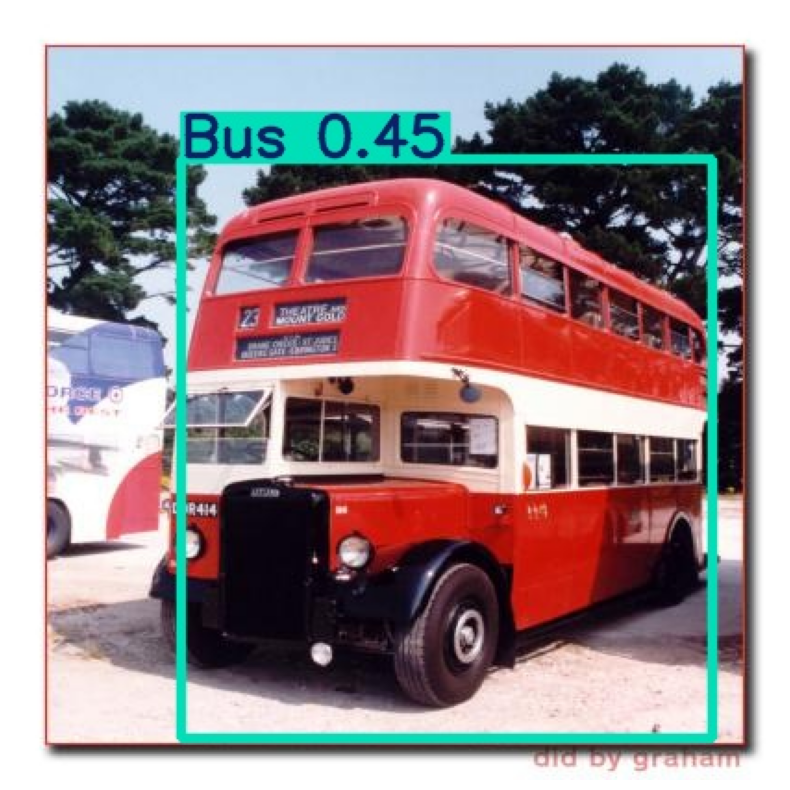

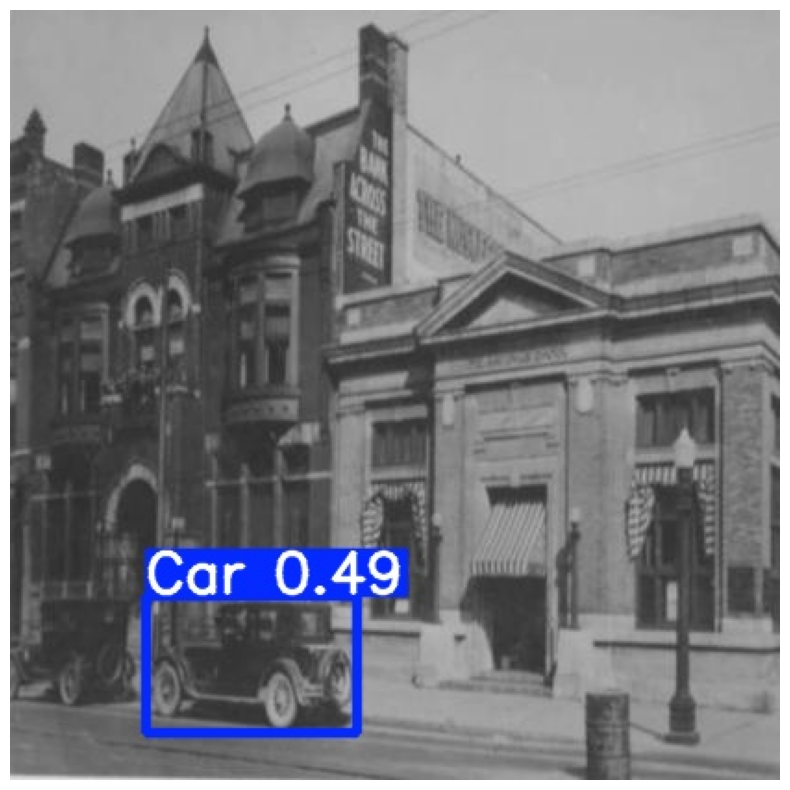

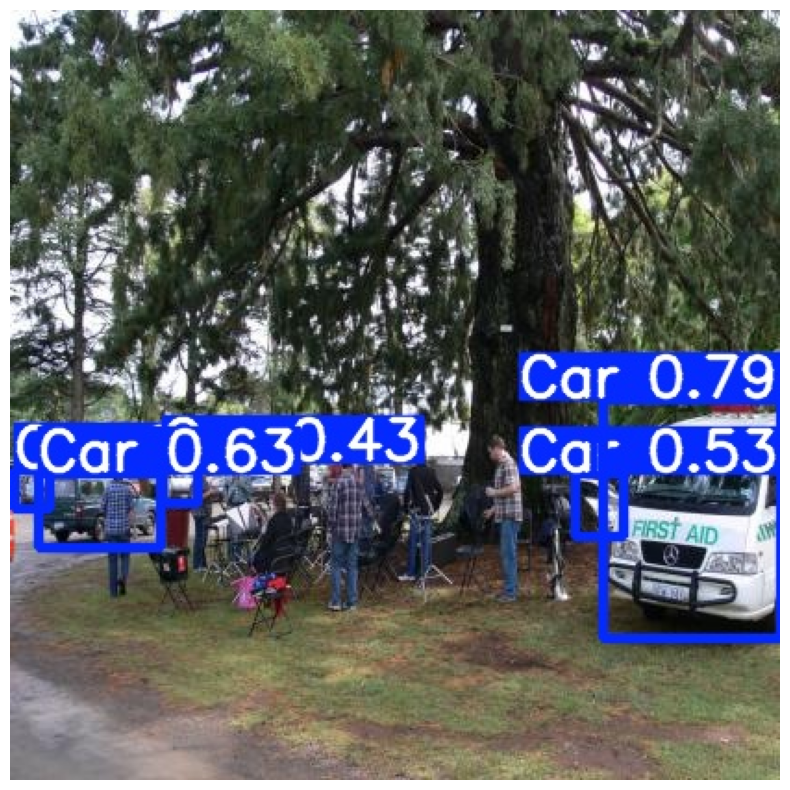

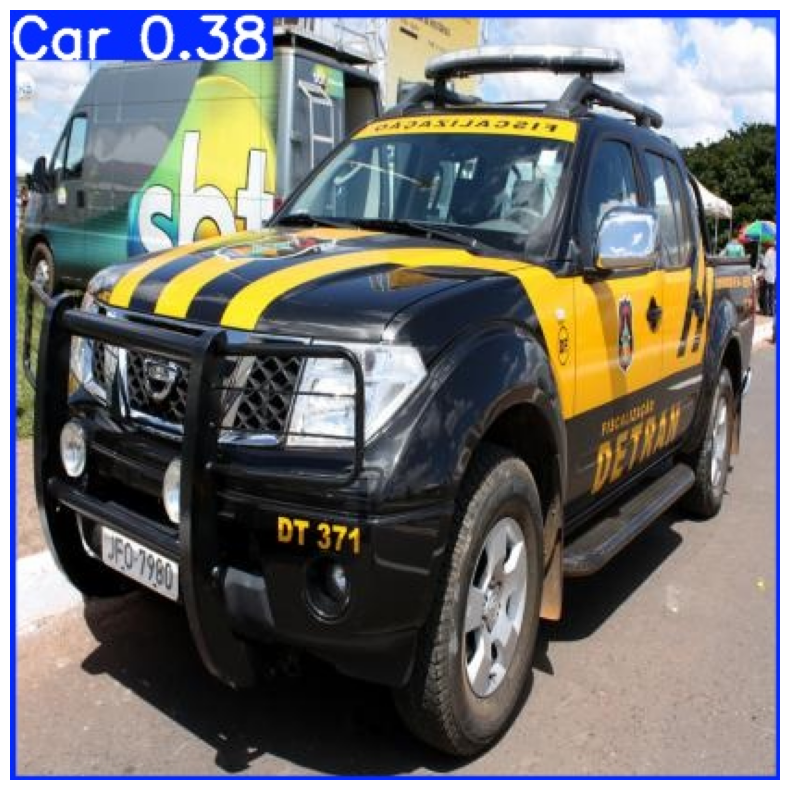

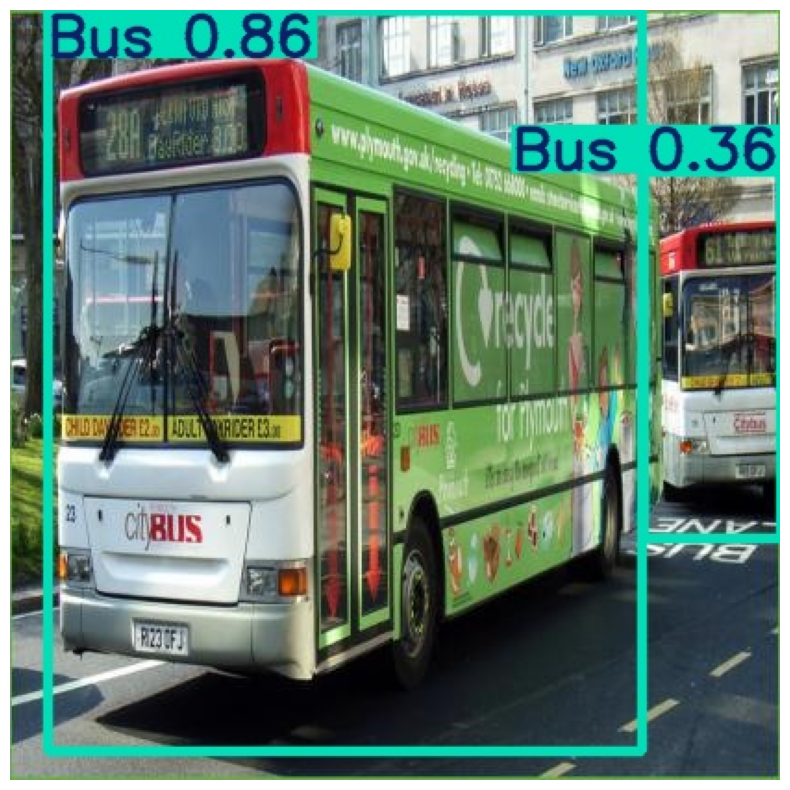

In [8]:
import cv2
import matplotlib.pyplot as plt
import glob

def plot_results(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Show first 5 results
for result in sorted(glob.glob('yolov5/runs/detect/exp/*.jpg'))[:5]:
    plot_results(result)